# 02 - Behavioural metrics

What the generate, validate, and fix loop did, straight from the records (no database needed): Pass@1 (the first candidate already validated), Pass@k (validated within the three-iteration budget), the mean number of validator iterations, wall-clock duration, exact token traffic, and USD cost. Cost is computed only for the Anthropic model, cache-aware (billed input equals uncached input plus cache-read plus cache-write); the local models are billed at zero. Everything is reported per target, then per model, in the canonical order.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "eval"))

import matplotlib.pyplot as plt
import pandas as pd
from harness import (
    DISPLAY_NAME,
    FIGURES_DIR,
    METRICS_BEHAVIOURAL_CSV,
    RECORDS_DIR,
    billed_input_tokens,
    load_dataset,
    load_records,
    order_models,
    plots,
    usd_cost,
)

OUT_CSV = METRICS_BEHAVIOURAL_CSV
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
records = load_records(RECORDS_DIR)
assert records, "No records found. Run 01_translation_run.ipynb first."
df = pd.DataFrame(records)
MODELS = order_models(df["model"].unique())
df["model"] = pd.Categorical(df["model"], MODELS, ordered=True)
print(f"Loaded {len(df)} records; models: {MODELS}")

Loaded 225 records; models: ['llama3.2:latest', 'qwen3-coder:30b', 'gemma4:26b', 'claude-opus-4-8', 'claude-opus-4-8-thinking']


## Helper methods

Derive the per-record behavioural signals (Pass@1, billed tokens, cost) using the harness pricing primitives, then define the per-model table (`query_results`), the per-target aggregation (`summary_by_model`), and the by-feature roll-up.

In [2]:
# Per-record signals (pricing primitives live in the harness; the rest is plain pandas).
df["pass_at_1"] = df["validation_passed"] & (df["iterations_used"] == 1)
df["billed_input_tokens"] = billed_input_tokens(df["input_tokens"], df["cache_read_tokens"], df["cache_creation_tokens"])
df["cost_usd"] = df.apply(lambda r: usd_cost(r["provider"], str(r["model"]), r["input_tokens"],
                          r["output_tokens"], r["cache_read_tokens"], r["cache_creation_tokens"]), axis=1)
if "thinking_used" not in df.columns:
    df["thinking_used"] = False

# Relabel to short display tags (after cost, which needs the functional id for pricing).
df["model"] = df["model"].map(lambda m: DISPLAY_NAME.get(m, m))
MODELS = order_models(df["model"].unique())
df["model"] = pd.Categorical(df["model"], MODELS, ordered=True)

MAX_ITER = int(df["iterations_used"].max()) if len(df) else 0
MODEL_COLS = ["query_id", "difficulty", "validation_passed", "pass_at_1", "iterations_used",
              "duration_seconds", "billed_input_tokens", "output_tokens", "cost_usd"]


def aggregate(group):
    ok = group["validation_passed"].sum()
    return pd.Series({
        "n": len(group),
        "pass@1": group["pass_at_1"].mean(),
        f"pass@{MAX_ITER}": group["validation_passed"].mean(),
        "mean_iterations": group["iterations_used"].mean(),
        "mean_duration_s": group["duration_seconds"].mean(),
        "total_input_tok": int(group["billed_input_tokens"].sum()),
        "total_output_tok": int(group["output_tokens"].sum()),
        "total_cost_usd": group["cost_usd"].sum(),
        "cost_per_success_usd": group["cost_usd"].sum() / ok if ok else float("nan"),
    })


def query_results(target, model):
    """Per-query behavioural signals for one (target, model) cell."""
    sub = df[(df["target"] == target) & (df["model"] == model)]
    if not len(sub):
        print(f"No records for {target}/{model}.")
        return None
    cols = MODEL_COLS + (["thinking_used"] if "thinking" in str(model) else [])
    return sub[cols].sort_values("query_id").reset_index(drop=True)


def summary_by_model(target):
    """Aggregate one target's records by model (canonical order)."""
    sub = df[df["target"] == target]
    if not len(sub):
        print(f"No records for {target}.")
        return None
    return sub.groupby("model", observed=True).apply(aggregate)


FEATURES = {q.id: q.sql_features for q in load_dataset("ldbc")}


def by_feature(frame, cols):
    """Mean of `cols` per (target, SQL feature label); explodes the multi-label feature list."""
    f = frame.copy()
    f["feature"] = f["query_id"].map(FEATURES)
    f = f.explode("feature").dropna(subset=["feature"])
    return f.groupby(["target", "feature"], observed=True)[cols].mean()

## Prerequisites

The records from notebook 01 must be on disk. Report coverage so a partial run is visible.

In [3]:
cov = df.groupby("target", observed=True)["model"].nunique().to_dict()
print("Records per target (distinct models):", cov)
print(f"{df['query_id'].nunique()} distinct queries; models: {MODELS}")

Records per target (distinct models): {'aql': 5, 'cypher': 5, 'gremlin': 5}
15 distinct queries; models: ['llama3.2:latest', 'qwen3-coder:30b', 'gemma4:26b', 'claude-opus-4-8', 'claude-opus-4-8-thinking']


## SQL to Cypher

### llama3.2:latest

In [4]:
query_results('cypher', 'llama3.2:latest')

,query_id,difficulty,validation_passed,pass_at_1,iterations_used,duration_seconds,billed_input_tokens,output_tokens,cost_usd
0,ldbc_q01,easy,True,True,1,6.945831,2404,35,0.0
1,ldbc_q02,easy,True,False,3,13.532050,8910,162,0.0
2,ldbc_q03,easy,True,True,1,8.171838,2401,185,0.0
3,ldbc_q04,hard,True,True,1,9.199575,3172,193,0.0
4,ldbc_q05,hard,True,True,1,4.061995,3461,81,0.0
5,ldbc_q06,medium,True,True,1,3.304163,2732,69,0.0
6,ldbc_q07,medium,True,True,1,5.110439,3199,104,0.0
7,ldbc_q08,hard,True,False,3,20.374309,9238,421,0.0
8,ldbc_q09,medium,True,True,1,3.901266,2821,85,0.0
9,ldbc_q10,hard,True,True,1,8.464310,3173,181,0.0


### qwen3-coder:30b

In [5]:
query_results('cypher', 'qwen3-coder:30b')

,query_id,difficulty,validation_passed,pass_at_1,iterations_used,duration_seconds,billed_input_tokens,output_tokens,cost_usd
0,ldbc_q01,easy,True,True,1,17.392788,2406,31,0.0
1,ldbc_q02,easy,True,True,1,19.496970,2890,71,0.0
2,ldbc_q03,easy,True,True,1,1.185505,2401,22,0.0
3,ldbc_q04,hard,True,True,1,3.422444,3175,49,0.0
4,ldbc_q05,hard,True,True,1,4.775432,3464,83,0.0
5,ldbc_q06,medium,True,True,1,3.332481,2734,47,0.0
6,ldbc_q07,medium,True,True,1,5.407516,3232,98,0.0
7,ldbc_q08,hard,True,True,1,5.113587,2841,93,0.0
8,ldbc_q09,medium,True,True,1,3.474695,2831,65,0.0
9,ldbc_q10,hard,True,True,1,4.065331,3175,42,0.0


### gemma4:26b

In [6]:
query_results('cypher', 'gemma4:26b')

,query_id,difficulty,validation_passed,pass_at_1,iterations_used,duration_seconds,billed_input_tokens,output_tokens,cost_usd
0,ldbc_q01,easy,True,True,1,37.736048,2735,422,0.0
1,ldbc_q02,easy,True,True,1,56.467919,3262,1215,0.0
2,ldbc_q03,easy,True,True,1,5.185734,2730,415,0.0
3,ldbc_q04,hard,True,True,1,12.430539,3563,1024,0.0
4,ldbc_q05,hard,True,True,1,24.740709,3864,2099,0.0
5,ldbc_q06,medium,True,True,1,15.012691,3094,1236,0.0
6,ldbc_q07,medium,True,True,1,22.617156,3642,1904,0.0
7,ldbc_q08,hard,True,True,1,24.555018,3222,2134,0.0
8,ldbc_q09,medium,True,True,1,23.373235,3203,2013,0.0
9,ldbc_q10,hard,True,True,1,10.780821,3566,828,0.0


### claude-opus-4-8

In [7]:
query_results('cypher', 'claude-opus-4-8')

,query_id,difficulty,validation_passed,pass_at_1,iterations_used,duration_seconds,billed_input_tokens,output_tokens,cost_usd
0,ldbc_q01,easy,True,True,1,2.084392,3825,50,0.025085
1,ldbc_q02,easy,True,True,1,7.168288,4566,87,0.030624
2,ldbc_q03,easy,True,True,1,1.633420,3823,45,0.003284
3,ldbc_q04,hard,True,True,1,2.711763,5186,76,0.034169
4,ldbc_q05,hard,True,True,1,2.775870,5709,96,0.037882
5,ldbc_q06,medium,True,True,1,2.871345,4385,73,0.029084
6,ldbc_q07,medium,True,True,1,2.847695,5152,140,0.035502
7,ldbc_q08,hard,True,True,1,2.855862,4592,151,0.032151
8,ldbc_q09,medium,True,True,1,3.690251,4572,118,0.031371
9,ldbc_q10,hard,True,True,1,2.324540,5188,89,0.005346


### claude-opus-4-8-thinking

In [8]:
query_results('cypher', 'claude-opus-4-8-thinking')

,query_id,difficulty,validation_passed,pass_at_1,iterations_used,duration_seconds,billed_input_tokens,output_tokens,cost_usd,thinking_used
0,ldbc_q01,easy,True,True,1,3.011928,3899,50,0.025548,False
1,ldbc_q02,easy,True,True,1,3.088816,4640,109,0.031636,True
2,ldbc_q03,easy,True,True,1,2.015992,3897,51,0.003471,False
3,ldbc_q04,hard,True,True,1,2.394907,5260,76,0.034631,False
4,ldbc_q05,hard,True,True,1,9.073131,5783,671,0.052720,True
5,ldbc_q06,medium,True,True,1,2.110404,4459,73,0.029546,False
6,ldbc_q07,medium,True,True,1,4.997396,5226,140,0.035965,False
7,ldbc_q08,hard,True,True,1,4.912796,4666,379,0.038314,True
8,ldbc_q09,medium,True,True,1,3.678660,4645,213,0.034204,True
9,ldbc_q10,hard,True,True,1,2.121678,5262,83,0.005233,False


### Aggregation by model

In [9]:
summary_by_model('cypher')

,n,pass@1,pass@3,mean_iterations,mean_duration_s,total_input_tok,total_output_tok,total_cost_usd,cost_per_success_usd
model,,,,,,,,,
llama3.2:latest,15.0,0.866667,1.0,1.266667,8.117859,56264.0,2148.0,0.000000,0.000000
qwen3-coder:30b,15.0,1.000000,1.0,1.000000,8.400243,43926.0,968.0,0.000000,0.000000
gemma4:26b,15.0,1.000000,1.0,1.000000,32.368910,49506.0,25596.0,0.000000,0.000000
claude-opus-4-8,15.0,1.000000,1.0,1.000000,2.960200,70926.0,1413.0,0.396223,0.026415
claude-opus-4-8-thinking,15.0,1.000000,1.0,1.000000,4.107374,72035.0,3150.0,0.445303,0.029687


### Figures

In [10]:
sub = df[df["target"] == 'cypher']
label = 'SQL -> Cypher'
prefix = 'cypher'

#### Pass / fail by query x model

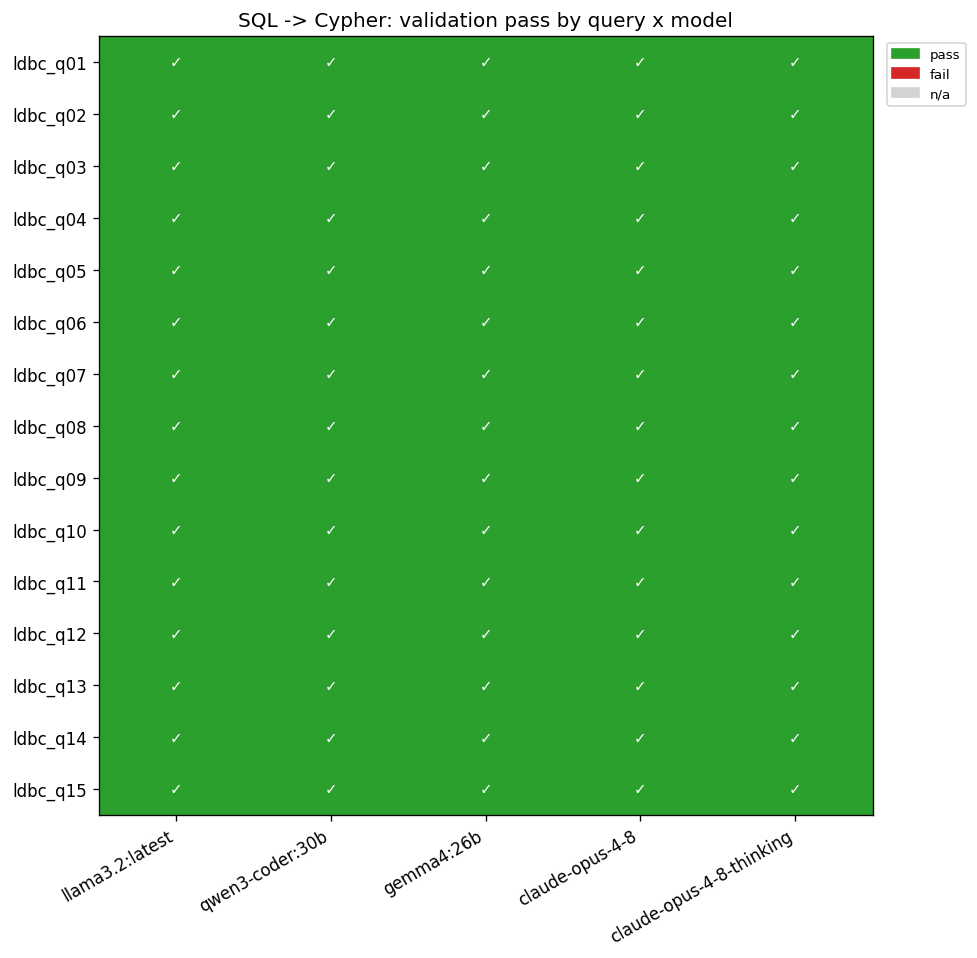

In [11]:
p = FIGURES_DIR / f"{prefix}_query_model_pass.png"
plots.query_model_heatmap(sub, "validation_passed", p, discrete=True, title=f"{label}: validation pass by query x model", cbar_label="pass")
plots.show(p)
plt.close("all")

#### Pass rate and Pass@1 per model

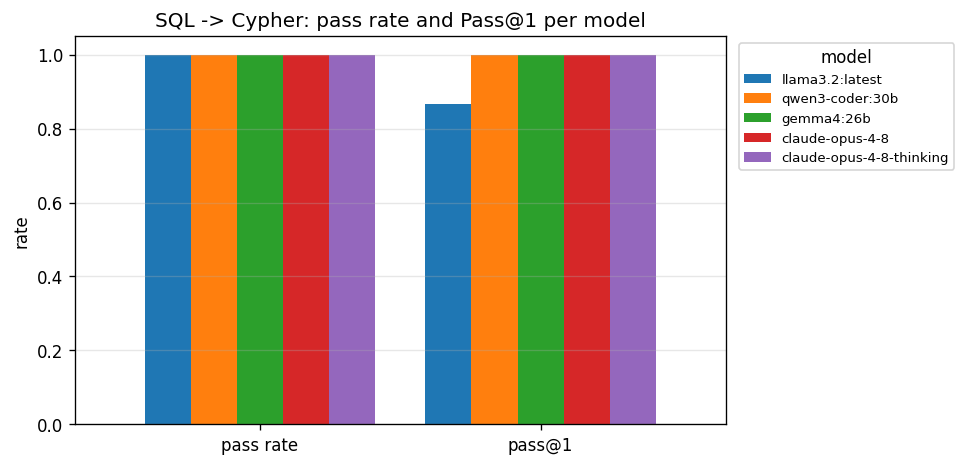

In [12]:
p = FIGURES_DIR / f"{prefix}_behavioural_pass_bars.png"
plots.per_model_bars(sub, ["validation_passed", "pass_at_1"], p, title=f"{label}: pass rate and Pass@1 per model", ylabel="rate", labels={"validation_passed": "pass rate", "pass_at_1": "pass@1"})
plots.show(p)
plt.close("all")

#### Cost and latency per model

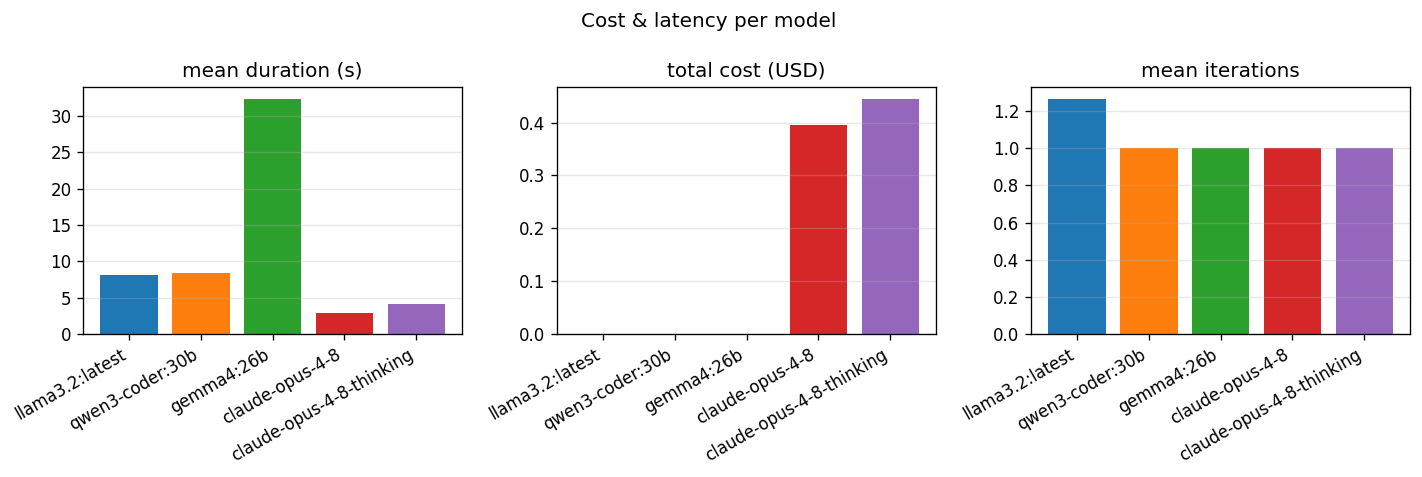

In [13]:
p = FIGURES_DIR / f"{prefix}_cost_latency.png"
plots.cost_latency(sub, p)
plots.show(p)
plt.close("all")

#### Pass@1 by difficulty

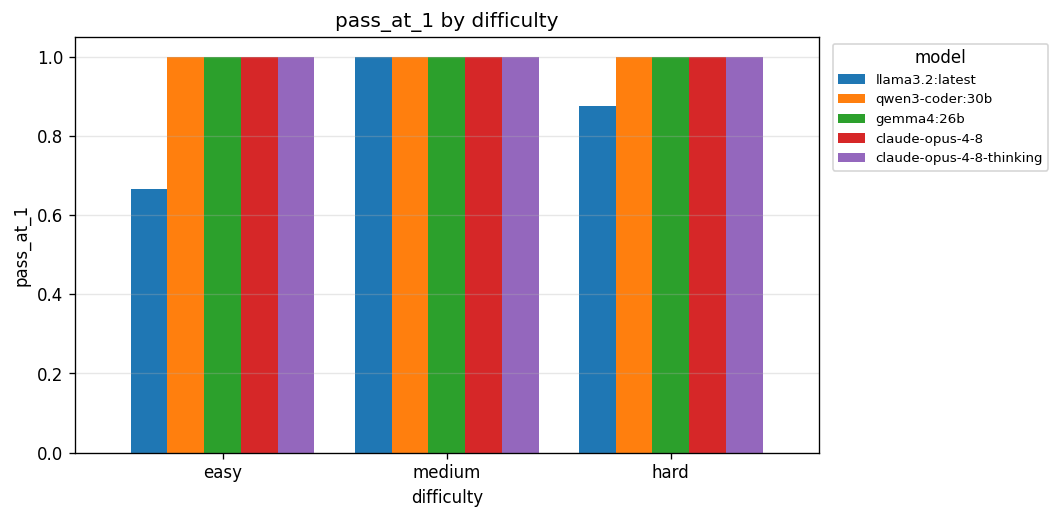

In [14]:
p = FIGURES_DIR / f"{prefix}_passrate_by_difficulty.png"
plots.passrate_by_difficulty(sub, "pass_at_1", p)
plots.show(p)
plt.close("all")

## SQL to AQL

### llama3.2:latest

In [15]:
query_results('aql', 'llama3.2:latest')

,query_id,difficulty,validation_passed,pass_at_1,iterations_used,duration_seconds,billed_input_tokens,output_tokens,cost_usd
0,ldbc_q01,easy,True,True,1,10.834274,3084,110,0.0
1,ldbc_q02,easy,True,True,1,8.007973,3412,163,0.0
2,ldbc_q03,easy,True,True,1,5.935551,3081,124,0.0
3,ldbc_q04,hard,True,False,2,16.883880,8603,329,0.0
4,ldbc_q05,hard,True,False,2,17.596494,9219,333,0.0
5,ldbc_q06,medium,True,True,1,9.611270,3462,198,0.0
6,ldbc_q07,medium,True,True,1,10.314666,3806,213,0.0
7,ldbc_q08,hard,True,False,3,37.362195,12952,746,0.0
8,ldbc_q09,medium,False,False,3,23.329497,11500,465,0.0
9,ldbc_q10,hard,True,False,2,28.752213,8779,555,0.0


### qwen3-coder:30b

In [16]:
query_results('aql', 'qwen3-coder:30b')

,query_id,difficulty,validation_passed,pass_at_1,iterations_used,duration_seconds,billed_input_tokens,output_tokens,cost_usd
0,ldbc_q01,easy,True,True,1,18.903891,3088,49,0.0
1,ldbc_q02,easy,True,True,1,3.055459,3441,61,0.0
2,ldbc_q03,easy,True,True,1,1.827960,3083,35,0.0
3,ldbc_q04,hard,True,True,1,6.200545,4018,88,0.0
4,ldbc_q05,hard,True,True,1,5.246304,4334,93,0.0
5,ldbc_q06,medium,True,True,1,4.275656,3466,55,0.0
6,ldbc_q07,medium,True,True,1,6.019845,3835,104,0.0
7,ldbc_q08,hard,True,True,1,6.641182,3601,113,0.0
8,ldbc_q09,medium,True,True,1,4.078746,3623,79,0.0
9,ldbc_q10,hard,True,True,1,4.485285,4018,51,0.0


### gemma4:26b

In [17]:
query_results('aql', 'gemma4:26b')

,query_id,difficulty,validation_passed,pass_at_1,iterations_used,duration_seconds,billed_input_tokens,output_tokens,cost_usd
0,ldbc_q01,easy,True,True,1,21.159219,3441,453,0.0
1,ldbc_q02,easy,True,True,1,14.435183,3818,1225,0.0
2,ldbc_q03,easy,True,True,1,5.401434,3436,429,0.0
3,ldbc_q04,hard,True,True,1,24.457997,4432,1981,0.0
4,ldbc_q05,hard,True,True,1,72.695676,4764,6385,0.0
5,ldbc_q06,medium,True,True,1,22.087202,3856,1801,0.0
6,ldbc_q07,medium,True,True,1,26.812581,4258,2302,0.0
7,ldbc_q08,hard,True,False,2,133.419983,8617,11571,0.0
8,ldbc_q09,medium,True,True,1,64.891218,4026,5565,0.0
9,ldbc_q10,hard,True,True,1,18.305811,4435,1447,0.0


### claude-opus-4-8

In [18]:
query_results('aql', 'claude-opus-4-8')

,query_id,difficulty,validation_passed,pass_at_1,iterations_used,duration_seconds,billed_input_tokens,output_tokens,cost_usd
0,ldbc_q01,easy,True,True,1,3.278285,5049,77,0.033410
1,ldbc_q02,easy,True,True,1,2.613209,5619,80,0.037030
2,ldbc_q03,easy,True,True,1,4.596436,5047,62,0.004321
3,ldbc_q04,hard,True,True,1,2.334190,6693,104,0.044288
4,ldbc_q05,hard,True,True,1,3.771293,7275,212,0.050570
5,ldbc_q06,medium,True,True,1,2.337970,5682,100,0.037865
6,ldbc_q07,medium,True,True,1,2.853055,6278,142,0.042590
7,ldbc_q08,hard,True,True,1,2.959778,5944,216,0.042226
8,ldbc_q09,medium,True,True,1,2.539799,5971,142,0.040716
9,ldbc_q10,hard,True,True,1,2.238497,6695,95,0.006249


### claude-opus-4-8-thinking

In [19]:
query_results('aql', 'claude-opus-4-8-thinking')

,query_id,difficulty,validation_passed,pass_at_1,iterations_used,duration_seconds,billed_input_tokens,output_tokens,cost_usd,thinking_used
0,ldbc_q01,easy,True,True,1,2.845516,5123,87,0.034123,True
1,ldbc_q02,easy,True,True,1,2.187544,5693,88,0.037692,True
2,ldbc_q03,easy,True,True,1,2.842752,5121,70,0.004558,True
3,ldbc_q04,hard,True,True,1,3.167358,6767,132,0.045450,True
4,ldbc_q05,hard,True,True,1,11.965075,7349,878,0.067683,True
5,ldbc_q06,medium,True,True,1,3.965427,5756,180,0.040328,True
6,ldbc_q07,medium,True,True,1,3.365681,6352,212,0.044803,True
7,ldbc_q08,hard,True,True,1,8.686078,6018,733,0.055614,True
8,ldbc_q09,medium,True,True,1,4.286678,6045,276,0.044529,True
9,ldbc_q10,hard,True,True,1,4.280975,6769,155,0.007786,True


### Aggregation by model

In [20]:
summary_by_model('aql')

,n,pass@1,pass@3,mean_iterations,mean_duration_s,total_input_tok,total_output_tok,total_cost_usd,cost_per_success_usd
model,,,,,,,,,
llama3.2:latest,15.0,0.466667,0.8,1.800000,21.446847,109403.0,5193.0,0.000000,0.000000
qwen3-coder:30b,15.0,1.000000,1.0,1.000000,7.132720,55295.0,1152.0,0.000000,0.000000
gemma4:26b,15.0,0.933333,1.0,1.066667,38.112693,65868.0,46451.0,0.000000,0.000000
claude-opus-4-8,15.0,1.000000,1.0,1.000000,3.060915,91382.0,1913.0,0.512205,0.034147
claude-opus-4-8-thinking,15.0,1.000000,1.0,1.000000,5.175006,92492.0,4823.0,0.590616,0.039374


### Figures

In [21]:
sub = df[df["target"] == 'aql']
label = 'SQL -> AQL'
prefix = 'aql'

#### Pass / fail by query x model

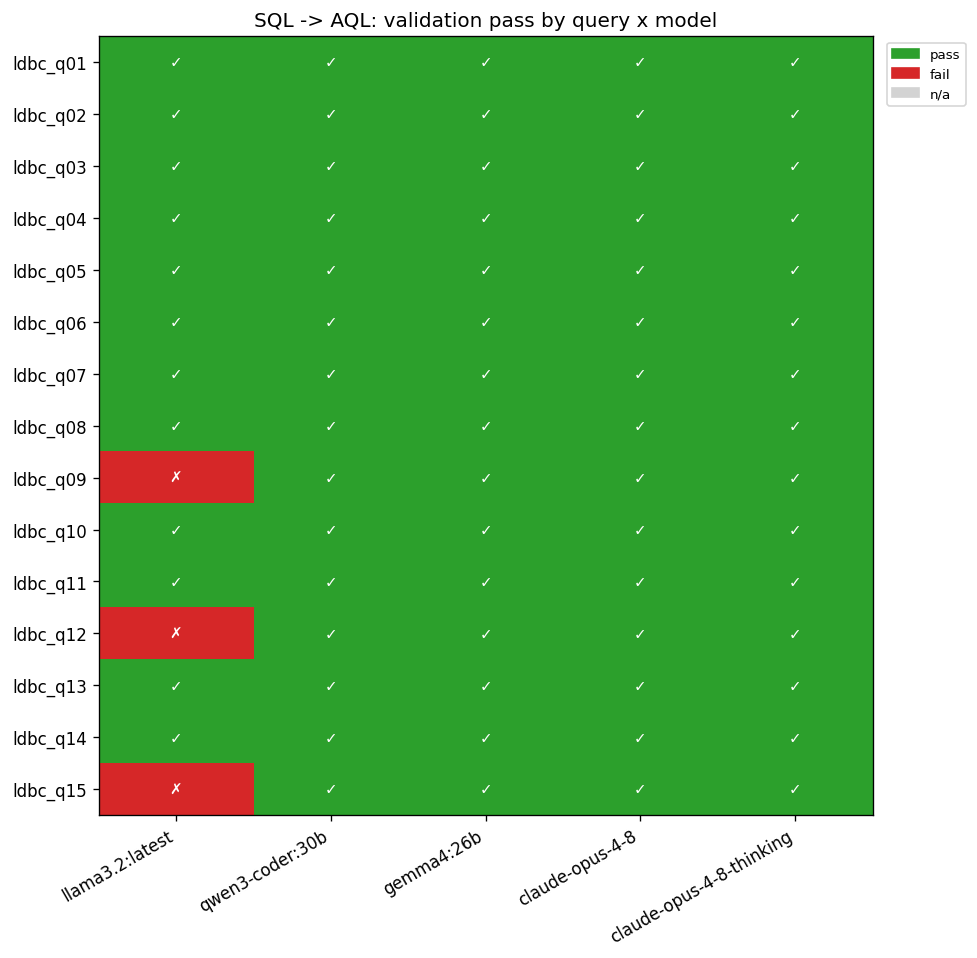

In [22]:
p = FIGURES_DIR / f"{prefix}_query_model_pass.png"
plots.query_model_heatmap(sub, "validation_passed", p, discrete=True, title=f"{label}: validation pass by query x model", cbar_label="pass")
plots.show(p)
plt.close("all")

#### Pass rate and Pass@1 per model

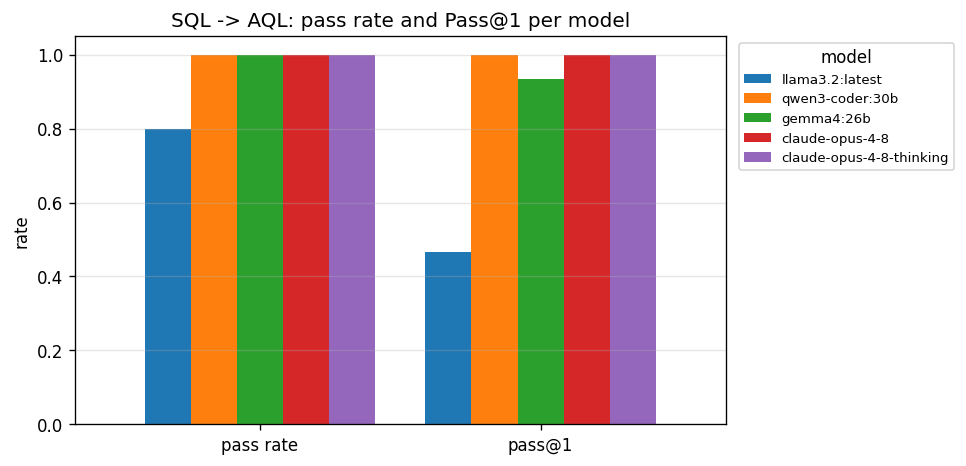

In [23]:
p = FIGURES_DIR / f"{prefix}_behavioural_pass_bars.png"
plots.per_model_bars(sub, ["validation_passed", "pass_at_1"], p, title=f"{label}: pass rate and Pass@1 per model", ylabel="rate", labels={"validation_passed": "pass rate", "pass_at_1": "pass@1"})
plots.show(p)
plt.close("all")

#### Cost and latency per model

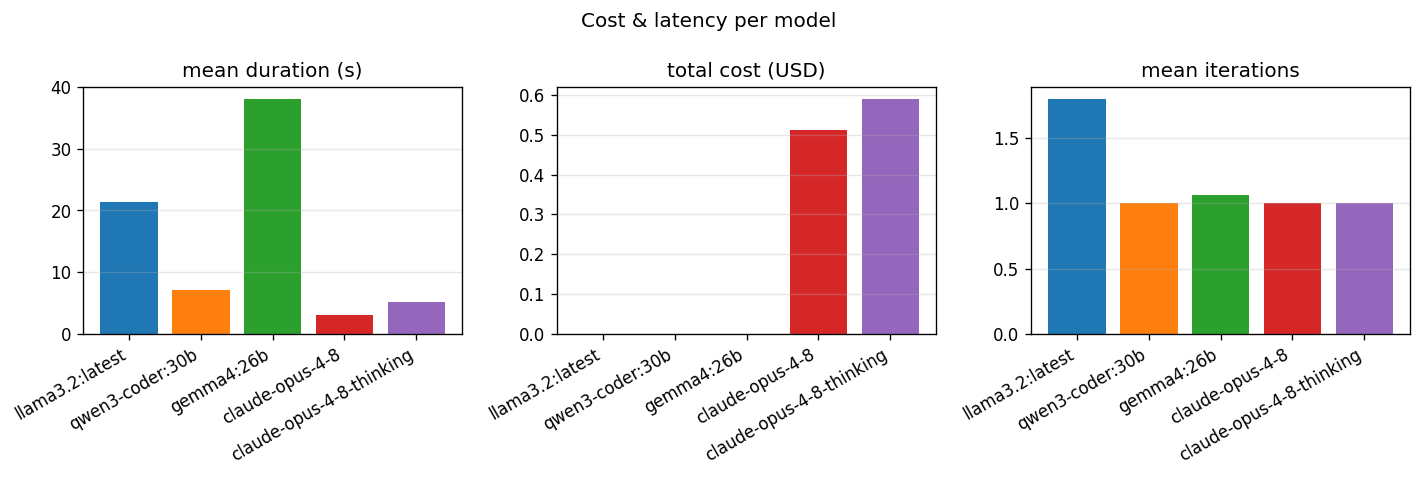

In [24]:
p = FIGURES_DIR / f"{prefix}_cost_latency.png"
plots.cost_latency(sub, p)
plots.show(p)
plt.close("all")

#### Pass@1 by difficulty

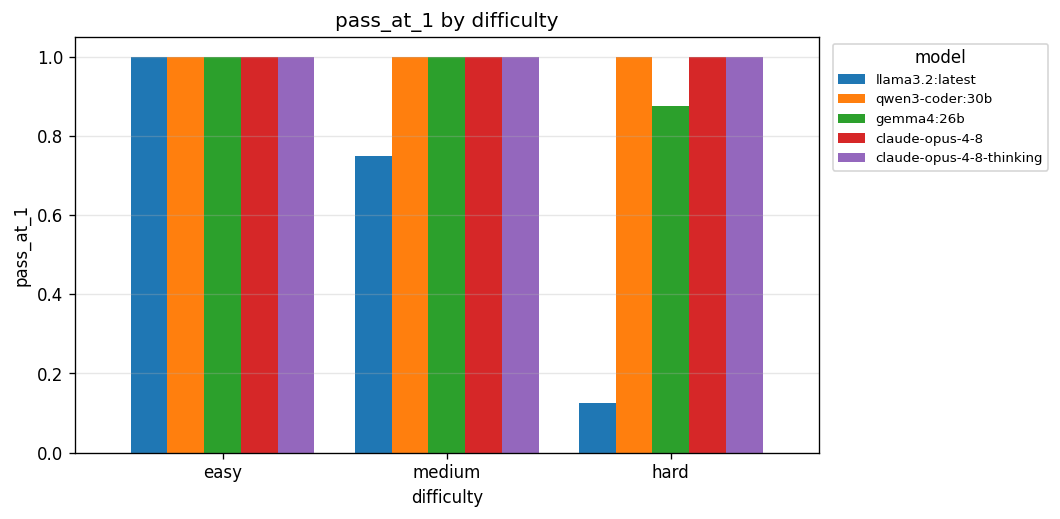

In [25]:
p = FIGURES_DIR / f"{prefix}_passrate_by_difficulty.png"
plots.passrate_by_difficulty(sub, "pass_at_1", p)
plots.show(p)
plt.close("all")

## SQL to Gremlin

### llama3.2:latest

In [26]:
query_results('gremlin', 'llama3.2:latest')

,query_id,difficulty,validation_passed,pass_at_1,iterations_used,duration_seconds,billed_input_tokens,output_tokens,cost_usd
0,ldbc_q01,easy,True,True,1,13.159977,2671,184,0.0
1,ldbc_q02,easy,False,False,3,30.228762,9857,662,0.0
2,ldbc_q03,easy,True,True,1,7.280943,2668,164,0.0
3,ldbc_q04,hard,False,False,3,36.715658,11898,725,0.0
4,ldbc_q05,hard,False,False,3,41.049272,12070,820,0.0
5,ldbc_q06,medium,False,False,3,17.293283,9717,369,0.0
6,ldbc_q07,medium,False,False,3,36.326841,11101,758,0.0
7,ldbc_q08,hard,True,True,1,32.553665,3183,698,0.0
8,ldbc_q09,medium,False,False,3,37.760254,11551,792,0.0
9,ldbc_q10,hard,False,False,3,29.893580,11047,613,0.0


### qwen3-coder:30b

In [27]:
query_results('gremlin', 'qwen3-coder:30b')

,query_id,difficulty,validation_passed,pass_at_1,iterations_used,duration_seconds,billed_input_tokens,output_tokens,cost_usd
0,ldbc_q01,easy,True,True,1,11.609653,2675,56,0.0
1,ldbc_q02,easy,True,True,1,2.872458,2992,72,0.0
2,ldbc_q03,easy,True,True,1,1.913921,2670,41,0.0
3,ldbc_q04,hard,True,False,3,18.067965,10842,340,0.0
4,ldbc_q05,hard,True,True,1,5.568143,3670,109,0.0
5,ldbc_q06,medium,True,True,1,3.427081,3045,58,0.0
6,ldbc_q07,medium,True,True,1,4.488420,3377,93,0.0
7,ldbc_q08,hard,False,False,1,NaN,0,0,0.0
8,ldbc_q09,medium,True,True,1,5.338304,3203,108,0.0
9,ldbc_q10,hard,True,True,1,5.841224,3387,94,0.0


### gemma4:26b

In [28]:
query_results('gremlin', 'gemma4:26b')

,query_id,difficulty,validation_passed,pass_at_1,iterations_used,duration_seconds,billed_input_tokens,output_tokens,cost_usd
0,ldbc_q01,easy,True,True,1,24.769073,2998,1239,0.0
1,ldbc_q02,easy,True,True,1,10.268602,3322,829,0.0
2,ldbc_q03,easy,True,True,1,8.568272,2993,697,0.0
3,ldbc_q04,hard,True,True,1,23.684939,3758,1962,0.0
4,ldbc_q05,hard,True,True,1,58.420987,4055,5006,0.0
5,ldbc_q06,medium,True,True,1,28.340513,3393,2372,0.0
6,ldbc_q07,medium,True,True,1,34.905015,3738,2995,0.0
7,ldbc_q08,hard,True,True,1,50.942750,3556,3696,0.0
8,ldbc_q09,medium,True,True,1,63.552989,3570,4642,0.0
9,ldbc_q10,hard,True,True,1,35.526123,3761,2985,0.0


### claude-opus-4-8

In [29]:
query_results('gremlin', 'claude-opus-4-8')

,query_id,difficulty,validation_passed,pass_at_1,iterations_used,duration_seconds,billed_input_tokens,output_tokens,cost_usd
0,ldbc_q01,easy,True,True,1,2.570988,4127,76,0.027623
1,ldbc_q02,easy,True,True,1,1.942554,4571,85,0.030605
2,ldbc_q03,easy,True,True,1,2.109440,4125,61,0.003835
3,ldbc_q04,hard,True,True,1,2.800566,5261,78,0.034688
4,ldbc_q05,hard,True,True,1,4.037739,5724,78,0.037526
5,ldbc_q06,medium,True,True,1,2.037096,4683,81,0.031146
6,ldbc_q07,medium,True,True,1,4.283523,5153,186,0.036659
7,ldbc_q08,hard,True,True,1,4.017482,4926,141,0.033989
8,ldbc_q09,medium,True,True,1,3.045629,4933,157,0.034604
9,ldbc_q10,hard,True,True,1,2.142205,5263,73,0.004983


### claude-opus-4-8-thinking

In [30]:
query_results('gremlin', 'claude-opus-4-8-thinking')

,query_id,difficulty,validation_passed,pass_at_1,iterations_used,duration_seconds,billed_input_tokens,output_tokens,cost_usd,thinking_used
0,ldbc_q01,easy,True,True,1,2.924066,4201,76,0.028085,False
1,ldbc_q02,easy,True,True,1,2.401232,4645,95,0.031317,True
2,ldbc_q03,easy,True,True,1,2.684893,4199,61,0.003872,False
3,ldbc_q04,hard,True,True,1,8.253819,5335,477,0.045125,True
4,ldbc_q05,hard,True,True,1,10.829722,5798,715,0.053914,True
5,ldbc_q06,medium,True,True,1,7.049105,4757,483,0.041659,True
6,ldbc_q07,medium,True,True,1,5.906375,5227,355,0.041346,True
7,ldbc_q08,hard,True,True,1,19.971580,5000,1640,0.071926,True
8,ldbc_q09,medium,True,True,1,9.505123,5007,715,0.049016,True
9,ldbc_q10,hard,True,True,1,4.775298,5337,298,0.010645,True


### Aggregation by model

In [31]:
summary_by_model('gremlin')

,n,pass@1,pass@3,mean_iterations,mean_duration_s,total_input_tok,total_output_tok,total_cost_usd,cost_per_success_usd
model,,,,,,,,,
llama3.2:latest,15.0,0.200000,0.200000,2.600000,30.926102,140396.0,9424.0,0.000000,0.000000
qwen3-coder:30b,15.0,0.666667,0.733333,1.400000,8.829270,64911.0,2006.0,0.000000,0.000000
gemma4:26b,15.0,0.933333,1.000000,1.066667,38.251002,57192.0,46426.0,0.000000,0.000000
claude-opus-4-8,15.0,1.000000,1.000000,1.000000,2.732615,73826.0,1383.0,0.411000,0.027400
claude-opus-4-8-thinking,15.0,1.000000,1.000000,1.000000,7.392287,74936.0,7279.0,0.564061,0.037604


### Figures

In [32]:
sub = df[df["target"] == 'gremlin']
label = 'SQL -> Gremlin'
prefix = 'gremlin'

#### Pass / fail by query x model

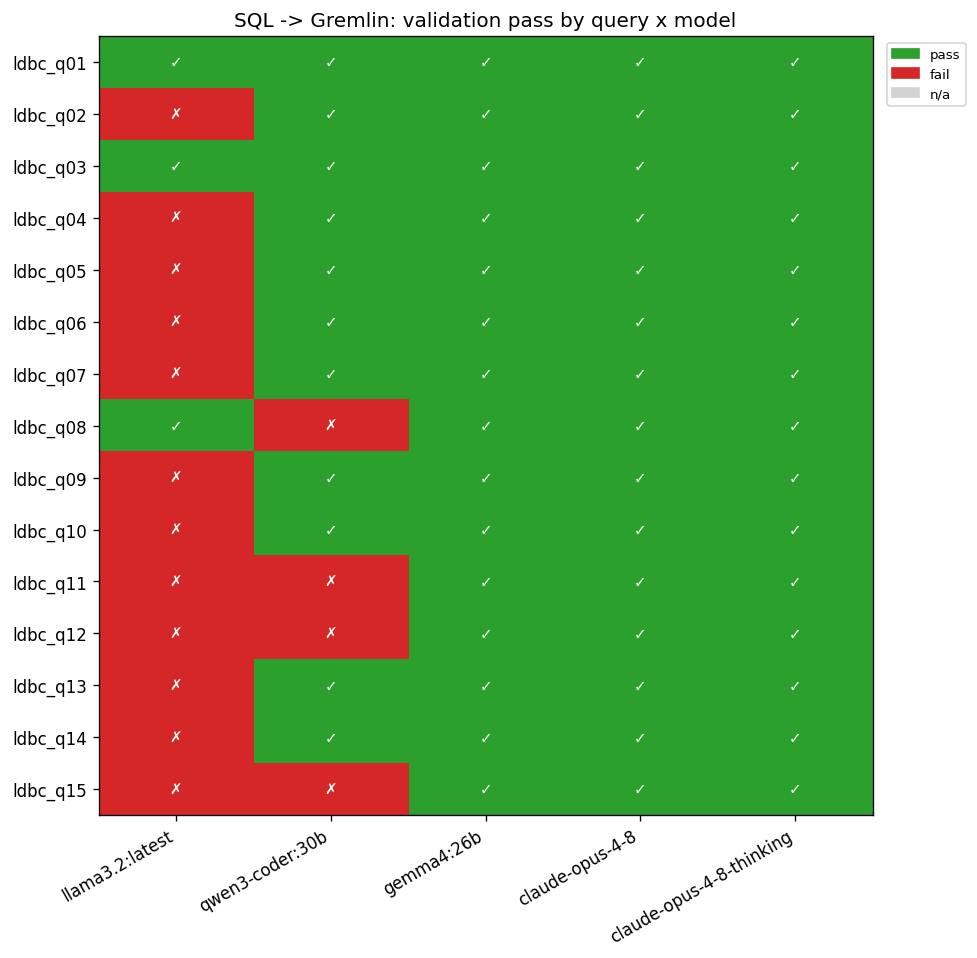

In [33]:
p = FIGURES_DIR / f"{prefix}_query_model_pass.png"
plots.query_model_heatmap(sub, "validation_passed", p, discrete=True, title=f"{label}: validation pass by query x model", cbar_label="pass")
plots.show(p)
plt.close("all")

#### Pass rate and Pass@1 per model

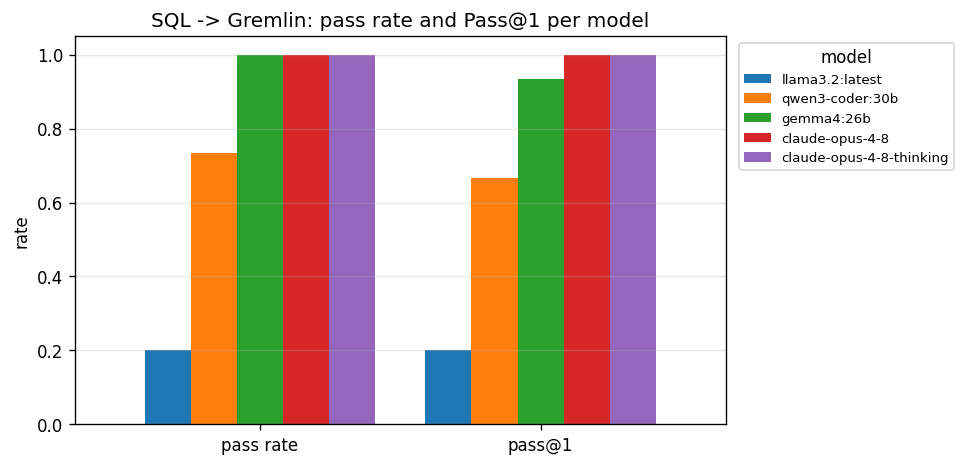

In [34]:
p = FIGURES_DIR / f"{prefix}_behavioural_pass_bars.png"
plots.per_model_bars(sub, ["validation_passed", "pass_at_1"], p, title=f"{label}: pass rate and Pass@1 per model", ylabel="rate", labels={"validation_passed": "pass rate", "pass_at_1": "pass@1"})
plots.show(p)
plt.close("all")

#### Cost and latency per model

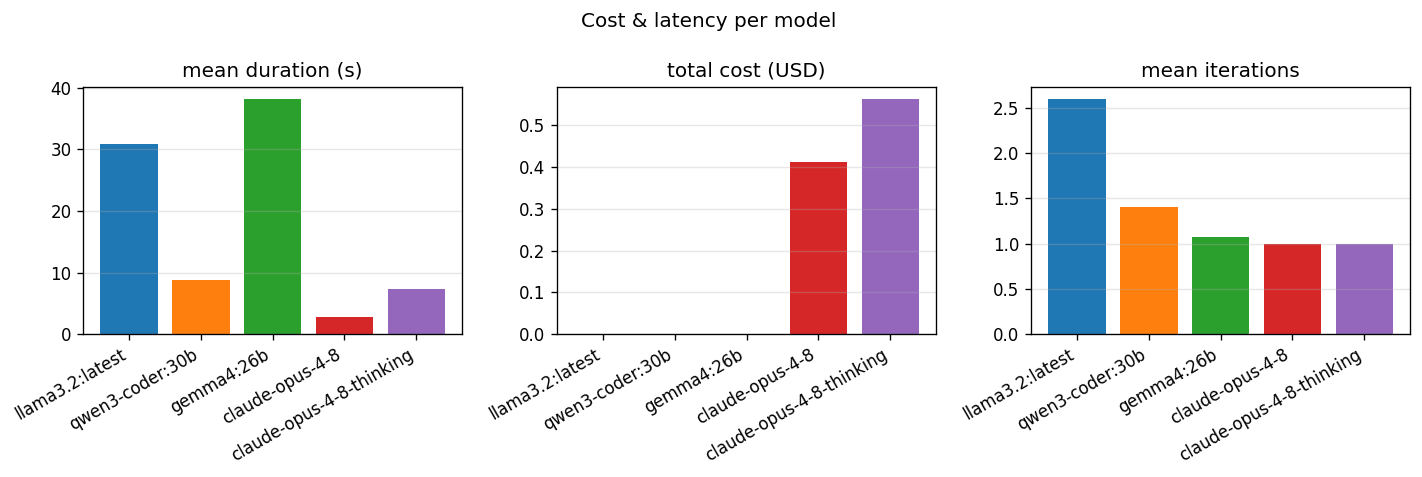

In [35]:
p = FIGURES_DIR / f"{prefix}_cost_latency.png"
plots.cost_latency(sub, p)
plots.show(p)
plt.close("all")

#### Pass@1 by difficulty

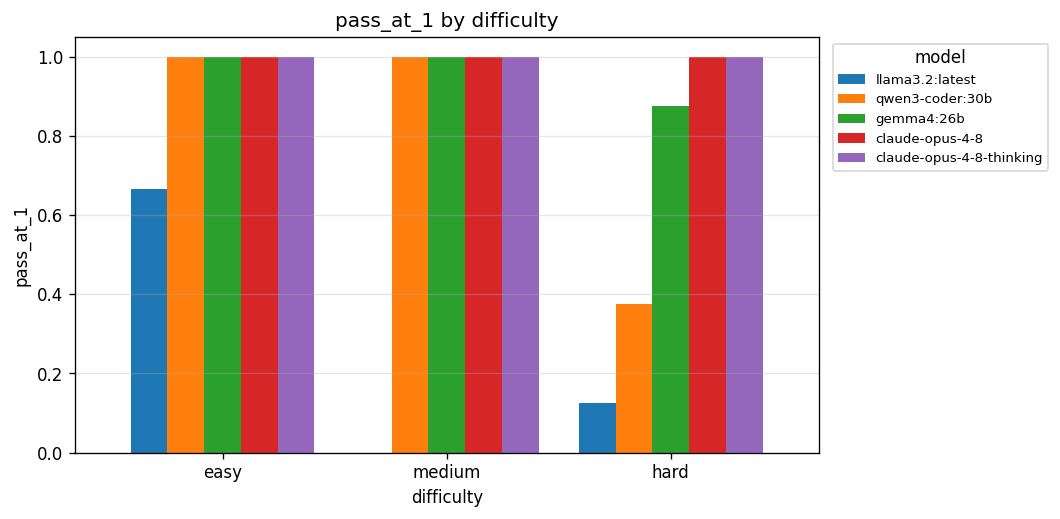

In [36]:
p = FIGURES_DIR / f"{prefix}_passrate_by_difficulty.png"
plots.passrate_by_difficulty(sub, "pass_at_1", p)
plots.show(p)
plt.close("all")

## Run-level summary

In [37]:
print("Overall:")
display(aggregate(df).to_frame("overall").T)
print("By target x model:")
display(df.groupby(["target", "model"], observed=True).apply(aggregate))
print("By target x difficulty:")
_bd = df.copy()
_bd["difficulty"] = pd.Categorical(_bd["difficulty"], ["easy", "medium", "hard"], ordered=True)
display(_bd.groupby(["target", "difficulty"], observed=True).apply(aggregate))
print("By target x SQL feature:")
display(by_feature(df, ["validation_passed", "pass_at_1", "iterations_used", "duration_seconds", "cost_usd"]))

Overall:


,n,pass@1,pass@3,mean_iterations,mean_duration_s,total_input_tok,total_output_tok,total_cost_usd,cost_per_success_usd
overall,225.0,0.871111,0.915556,1.213333,14.6527,1118358.0,159325.0,2.919408,0.014172


By target x model:


n    pass@1    pass@3  mean_iterations  \
target  model                                                                 
aql     llama3.2:latest           15.0  0.466667  0.800000         1.800000   
        qwen3-coder:30b           15.0  1.000000  1.000000         1.000000   
        gemma4:26b                15.0  0.933333  1.000000         1.066667   
        claude-opus-4-8           15.0  1.000000  1.000000         1.000000   
        claude-opus-4-8-thinking  15.0  1.000000  1.000000         1.000000   
cypher  llama3.2:latest           15.0  0.866667  1.000000         1.266667   
        qwen3-coder:30b           15.0  1.000000  1.000000         1.000000   
        gemma4:26b                15.0  1.000000  1.000000         1.000000   
        claude-opus-4-8           15.0  1.000000  1.000000         1.000000   
        claude-opus-4-8-thinking  15.0  1.000000  1.000000         1.000000   
gremlin llama3.2:latest           15.0  0.200000  0.200000         2.600000   
        qwen3-coder:30b           15.0  0.666667  0.733333         1.400000   
        gemma4:26b                15.0  0.933333  1.000000         1.066667   
        claude-opus-4-8           15.0  1.000000  1.000000         1.000000   
        claude-opus-4-8-thinking  15.0  1.000000  1.000000         1.000000   

                                  mean_duration_s  total_input_tok  \
target  model                                                        
aql     llama3.2:latest                 21.446847         109403.0   
        qwen3-coder:30b                  7.132720          55295.0   
        gemma4:26b                      38.112693          65868.0   
        claude-opus-4-8                  3.060915          91382.0   
        claude-opus-4-8-thinking         5.175006          92492.0   
cypher  llama3.2:latest                  8.117859          56264.0   
        qwen3-coder:30b                  8.400243          43926.0   
        gemma4:26b                      32.368910          49506.0   
        claude-opus-4-8                  2.960200          70926.0   
        claude-opus-4-8-thinking         4.107374          72035.0   
gremlin llama3.2:latest                 30.926102         140396.0   
        qwen3-coder:30b                  8.829270          64911.0   
        gemma4:26b                      38.251002          57192.0   
        claude-opus-4-8                  2.732615          73826.0   
        claude-opus-4-8-thinking         7.392287          74936.0   

                                  total_output_tok  total_cost_usd  \
target  model                                                        
aql     llama3.2:latest                     5193.0        0.000000   
        qwen3-coder:30b                     1152.0        0.000000   
        gemma4:26b                         46451.0        0.000000   
        claude-opus-4-8                     1913.0        0.512205   
        claude-opus-4-8-thinking            4823.0        0.590616   
cypher  llama3.2:latest                     2148.0        0.000000   
        qwen3-coder:30b                      968.0        0.000000   
        gemma4:26b                         25596.0        0.000000   
        claude-opus-4-8                     1413.0        0.396223   
        claude-opus-4-8-thinking            3150.0        0.445303   
gremlin llama3.2:latest                     9424.0        0.000000   
        qwen3-coder:30b                     2006.0        0.000000   
        gemma4:26b                         46426.0        0.000000   
        claude-opus-4-8                     1383.0        0.411000   
        claude-opus-4-8-thinking            7279.0        0.564061   

                                  cost_per_success_usd  
target  model                                           
aql     llama3.2:latest                       0.000000  
        qwen3-coder:30b                       0.000000  
        gemma4:26b                            0.000000  
        claude-opus-4-8   

By target x difficulty:


n    pass@1    pass@3  mean_iterations  \
target  difficulty                                              
aql     easy        15.0  1.000000  1.000000         1.000000   
        medium      20.0  0.950000  0.950000         1.100000   
        hard        40.0  0.800000  0.950000         1.275000   
cypher  easy        15.0  0.933333  1.000000         1.133333   
        medium      20.0  1.000000  1.000000         1.000000   
        hard        40.0  0.975000  1.000000         1.050000   
gremlin easy        15.0  0.933333  0.933333         1.133333   
        medium      20.0  0.800000  0.800000         1.400000   
        hard        40.0  0.675000  0.725000         1.525000   

                    mean_duration_s  total_input_tok  total_output_tok  \
target  difficulty                                                       
aql     easy               7.194979          61536.0            3113.0   
        medium            11.802624         102765.0           14080.0   
        hard              19.498638         250139.0           42339.0   
cypher  easy              12.341168          54789.0            2950.0   
        medium             7.061888          75595.0            8115.0   
        hard              12.824088         162273.0           22210.0   
gremlin easy               8.353656          58714.0            4398.0   
        medium            18.639360         110062.0           20650.0   
        hard              21.216278         242485.0           41470.0   

                    total_cost_usd  cost_per_success_usd  
target  difficulty                                        
aql     easy              0.151134              0.010076  
        medium            0.341165              0.017956  
        hard              0.610523              0.016066  
cypher  easy              0.119648              0.007977  
        medium            0.262158              0.013108  
        hard              0.459721              0.011493  
gremlin easy              0.125337              0.008953  
        medium            0.305152              0.019072  
        hard              0.544571              0.018778

By target x SQL feature:


validation_passed  pass_at_1  iterations_used  \
target  feature                                                      
aql     aggregation           1.000000   0.840000         1.160000   
        cte                   0.800000   0.800000         1.400000   
        distinct              0.900000   0.700000         1.500000   
        join                  0.945455   0.836364         1.236364   
        order_limit           0.933333   0.800000         1.266667   
        subquery              1.000000   0.900000         1.100000   
        temporal              1.000000   1.000000         1.000000   
        union                 0.866667   0.800000         1.333333   
cypher  aggregation           1.000000   1.000000         1.000000   
        cte                   1.000000   1.000000         1.000000   
        distinct              1.000000   0.900000         1.200000   
        join                  1.000000   0.981818         1.036364   
        order_limit           1.000000   1.000000         1.000000   
        subquery              1.000000   1.000000         1.000000   
        temporal              1.000000   0.900000         1.200000   
        union                 1.000000   1.000000         1.000000   
gremlin aggregation           0.760000   0.720000         1.560000   
        cte                   0.600000   0.600000         1.400000   
        distinct              0.700000   0.600000         1.500000   
        join                  0.745455   0.709091         1.490909   
        order_limit           0.733333   0.700000         1.533333   
        subquery              0.800000   0.800000         1.400000   
        temporal              0.800000   0.800000         1.400000   
        union                 0.666667   0.600000         1.600000   

                     duration_seconds  cost_usd  
target  feature                                  
aql     aggregation         13.041788  0.013167  
        cte                 32.340101  0.020009  
        distinct            29.836127  0.019947  
        join                17.761377  0.015991  
        order_limit         18.052932  0.014138  
        subquery            15.039710  0.019042  
        temporal             7.966520  0.016212  
        union               25.484493  0.021329  
cypher  aggregation          7.456586  0.009907  
        cte                 40.324591  0.014311  
        distinct            12.393824  0.014522  
        join                11.231004  0.012002  
        order_limit         13.021579  0.010611  
        subquery             8.192317  0.015236  
        temporal            14.073424  0.013373  
        union               20.878450  0.015794  
gremlin aggregation         20.793577  0.010949  
        cte                 21.221375  0.019031  
        distinct            29.951798  0.018681  
        join                21.463220  0.014366  
        order_limit         21.186192  0.012726  
        subquery            16.136098  0.015103  
        temporal            13.362378  0.013993  
        union               26.205148  0.017833

## Save per-record CSV

In [38]:
out = df[["dataset", "target", "model", "provider", "query_id", "difficulty",
          "validation_passed", "pass_at_1", "iterations_used", "duration_seconds",
          "input_tokens", "output_tokens", "cache_read_tokens", "cache_creation_tokens",
          "billed_input_tokens", "cost_usd", "thinking_used"]].copy()
out["model"] = out["model"].astype(str)
out.to_csv(OUT_CSV, index=False)
print(f"Wrote {len(out)} rows to {OUT_CSV}")

Wrote 225 rows to /Users/ivona.obonova/school/sql2graph/sql2graph/eval/outputs/metrics/metrics_behavioural.csv


## Summary

Behavioural metrics measure validity and efficiency, not semantics: a model can validate every query yet return the wrong rows. Pass@k close to 1 on Cypher and AQL means the loop's grammar-feedback repair works there; Gremlin is where validity itself becomes a capability signal. Cost and latency here set up the reasoning-versus-terse contrast the execution notebook pays off.

Wrote `metrics_behavioural.csv`. Proceed to **`03_structural_metrics.ipynb`**.